In [1]:
!pip install -q duckdb
from google.colab import userdata
import duckdb

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
for t in ['dim_content.parquet', 'fact_content_daily_performance_sample.parquet']:
    print('\n===', t)
    print(con.sql(f"DESCRIBE SELECT * FROM read_parquet('{REL}/{t}')").df()[['column_name', 'column_type']].to_string())


=== dim_content.parquet
                   column_name column_type
0               client_hash_id     VARCHAR
1              content_hash_id     VARCHAR
2              keyword_hash_id     VARCHAR
3                  url_hash_id     VARCHAR
4           keyword_char_count      BIGINT
5          keyword_token_count      BIGINT
6               url_char_count      BIGINT
7         content_created_date        DATE
8         content_updated_date        DATE
9                 content_type     VARCHAR
10               search_volume      BIGINT
11                 competition      DOUBLE
12           competition_level     VARCHAR
13                         cpc      DOUBLE
14                 main_intent     VARCHAR
15                   backlinks      BIGINT
16              category_count      BIGINT
17        keyword_created_date        DATE
18               provider_used     VARCHAR
19                  model_used     VARCHAR
20                  char_count      BIGINT
21                  word_coun

In [2]:
SAMPLE = f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')"

print(con.sql(f"""
SELECT COUNT(*)                                   AS rows,
       COUNT(DISTINCT content_hash_id)            AS pages,
       COUNT(DISTINCT client_hash_id)             AS clients,
       MIN(report_date)                           AS first_day,
       MAX(report_date)                           AS last_day,
       ROUND(AVG(gsc_data_available::INT), 3)     AS share_gsc_available
FROM {SAMPLE}
""").df().T)

print(con.sql(f"""
SELECT COUNT(*) AS gsc_rows,
       COUNT(DISTINCT content_hash_id) AS gsc_pages,
       ROUND(AVG(gsc_impressions),1)   AS avg_impr,
       ROUND(SUM(gsc_clicks)*1.0/SUM(gsc_impressions),4) AS overall_ctr,
       ROUND(AVG(gsc_avg_position),1)  AS avg_pos
FROM {SAMPLE}
WHERE gsc_data_available AND gsc_impressions > 0
""").df().T)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                                       0
rows                            11694072
pages                             409205
clients                               65
first_day            2026-06-01 00:00:00
last_day             2026-06-30 00:00:00
share_gsc_available                0.332


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                        0
gsc_rows     3.878937e+06
gsc_pages    2.086360e+05
avg_impr     5.570000e+01
overall_ctr  5.600000e-03
avg_pos      2.130000e+01


In [3]:
from huggingface_hub import HfApi
files = HfApi().list_repo_files('FlyRank/internship-warehouse', repo_type='dataset', token=HF_TOKEN)
months = sorted({f.split('/')[1].replace('month=', '') for f in files
                 if f.startswith('fact_content_daily_performance/month=')})
print(months)

['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']


In [4]:
MONTHS = ['2026-04', '2026-05', '2026-06']
paths = ", ".join(f"'{REL}/fact_content_daily_performance/month={m}/*.parquet'" for m in MONTHS)

con.execute(f"""
CREATE OR REPLACE TABLE daily AS
SELECT hash(content_hash_id)  AS page,
       report_date::DATE      AS dt,
       gsc_clicks::INTEGER    AS clicks,
       gsc_impressions::INTEGER AS impr,
       gsc_avg_position       AS pos
FROM read_parquet([{paths}])
WHERE gsc_data_available AND gsc_impressions > 0
""")

print(con.sql("""
SELECT COUNT(*) AS rows, COUNT(DISTINCT page) AS pages,
       MIN(dt) AS first_day, MAX(dt) AS last_day
FROM daily
""").df().T)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                             0
rows                  12153419
pages                   271046
first_day  2026-04-01 00:00:00
last_day   2026-06-30 00:00:00


In [5]:
import numpy as np, pandas as pd

WINDOW_DAYS, MIN_IMPR, MAX_POS, UNDER_RATIO = 28, 100, 20, 0.75

def agg_window(start, end):
    d = con.execute(f"""
        SELECT page, SUM(clicks)::DOUBLE AS clicks, SUM(impr)::DOUBLE AS impr,
               SUM(pos*impr)/NULLIF(SUM(impr),0) AS pos,
               COUNT(DISTINCT dt) AS days_active
        FROM daily
        WHERE dt >= DATE '{start}' AND dt < DATE '{end}'
        GROUP BY page""").df()
    d['ctr'] = d['clicks'] / d['impr']
    return d

def add_peer_ctr(d):
    d = d.copy()
    d['bucket'] = pd.cut(d['pos'], [0,1.5,3,5,8,12,20,1000], labels=False)
    med = d[d.impr >= MIN_IMPR].groupby('bucket')['ctr'].median().rename('peer_ctr')
    d = d.join(med, on='bucket')
    d['ctr_ratio'] = d['ctr'] / d['peer_ctr']
    return d

def build_frame(cutoff):
    T = pd.Timestamp(cutoff)
    p_start = T - pd.Timedelta(days=WINDOW_DAYS)
    p_mid   = T - pd.Timedelta(days=WINDOW_DAYS // 2)
    f_end   = T + pd.Timedelta(days=WINDOW_DAYS)
    past   = add_peer_ctr(agg_window(p_start.date(), T.date()))
    first  = agg_window(p_start.date(), p_mid.date())[['page','impr']].rename(columns={'impr':'impr_first'})
    second = agg_window(p_mid.date(), T.date())[['page','impr']].rename(columns={'impr':'impr_second'})
    fut    = add_peer_ctr(agg_window(T.date(), f_end.date()))
    df = past.merge(first, on='page', how='left').merge(second, on='page', how='left')
    df = df.merge(fut[['page','impr','pos','ctr_ratio']].rename(
            columns={'impr':'f_impr','pos':'f_pos','ctr_ratio':'f_ctr_ratio'}), on='page', how='inner')
    df = df[(df.impr >= MIN_IMPR) & (df.pos <= MAX_POS) &
            (df.f_impr >= MIN_IMPR) & (df.f_pos <= MAX_POS)].copy()
    df['impr_trend'] = (df['impr_second'].fillna(0) + 1) / (df['impr_first'].fillna(0) + 1)
    df['label'] = (df['f_ctr_ratio'] < UNDER_RATIO).astype(int)
    return df

max_d = pd.Timestamp('2026-06-30')
TEST_CUTOFF  = max_d - pd.Timedelta(days=WINDOW_DAYS)      # 2026-06-02
TRAIN_CUTOFF = TEST_CUTOFF - pd.Timedelta(days=WINDOW_DAYS) # 2026-05-05
train_df = build_frame(TRAIN_CUTOFF)
test_df  = build_frame(TEST_CUTOFF)

print('cutoffs:', TRAIN_CUTOFF.date(), TEST_CUTOFF.date())
print('rows train/test:', len(train_df), len(test_df))
print('under-capture rate train/test:', round(train_df.label.mean(), 3), round(test_df.label.mean(), 3))
print('test pages also in train:', f"{len(set(test_df.page) & set(train_df.page)) / len(test_df):.1%}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

cutoffs: 2026-05-05 2026-06-02
rows train/test: 57588 54566
under-capture rate train/test: 0.423 0.421
test pages also in train: 83.1%


In [6]:
print('under-capture rate train/test:', round(train_df.label.mean(), 3), round(test_df.label.mean(), 3))
print('test pages also in train:', f"{len(set(test_df.page) & set(train_df.page)) / len(test_df):.1%}")
print(train_df[['impr','ctr','pos','ctr_ratio','impr_trend']].describe().round(3))

under-capture rate train/test: 0.423 0.421
test pages also in train: 83.1%
             impr        ctr        pos  ctr_ratio  impr_trend
count   57588.000  57588.000  57588.000  57497.000   57588.000
mean     3530.132      0.004      7.729        inf      29.385
std      8603.799      0.005      3.791        NaN     199.317
min       100.000      0.000      0.107      0.000       0.001
25%       444.000      0.000      5.094      0.206       0.519
50%      1130.000      0.002      6.859      1.250       0.786
75%      3205.000      0.005      9.548      2.970       1.130
max    676381.000      0.191     19.998        inf    9251.000


In [10]:
def add_peer_ctr(d):
    d = d.copy()
    d['bucket'] = pd.cut(d['pos'], [0,1.5,3,5,8,12,20,1000], labels=False)
    med = d[d.impr >= MIN_IMPR].groupby('bucket')['ctr'].median().rename('peer_ctr')
    d = d.join(med, on='bucket')
    d.loc[d['peer_ctr'] <= 0, 'peer_ctr'] = np.nan
    d['ctr_ratio'] = d['ctr'] / d['peer_ctr']
    return d

def build_frame_clean(cutoff):
    df = build_frame(cutoff)
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['ctr_ratio', 'f_ctr_ratio'])
    df['label'] = (df['f_ctr_ratio'] < UNDER_RATIO).astype(int)
    df['log_impr']    = np.log1p(df['impr'])
    df['log_trend']   = np.log(df['impr_trend'].clip(0.01, 100))
    df['ctr_ratio_c'] = df['ctr_ratio'].clip(0, 10)
    return df

train_df = build_frame_clean(TRAIN_CUTOFF)
test_df  = build_frame_clean(TEST_CUTOFF)
print('rows train/test:', len(train_df), len(test_df))
print('under-capture rate:', round(train_df.label.mean(), 3), round(test_df.label.mean(), 3))
print('ctr_ratio max (train):', train_df.ctr_ratio.max().round(2))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

rows train/test: 57302 54566
under-capture rate: 0.423 0.421


AttributeError: 'float' object has no attribute 'round'

In [8]:
print('ctr_ratio max (train):', round(float(train_df['ctr_ratio'].max()), 2))
print('inf/NaN left:', int(train_df['ctr_ratio'].isna().sum()), int(np.isinf(train_df['ctr_ratio']).sum()))

ctr_ratio max (train): 90.54
inf/NaN left: 0 0


In [11]:
!pip install -q lightgbm scikit-learn
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import lightgbm as lgb

FEAT_LGB = ['impr','clicks','ctr','pos','days_active','bucket','ctr_ratio','impr_trend']
FEAT_LOG = ['log_impr','ctr','pos','days_active','bucket','ctr_ratio_c','log_trend']
y_tr, y_te = train_df['label'], test_df['label']
K = 1000

def prec_at_k(y, s, k):
    return float(np.mean(np.asarray(y)[np.argsort(-s)[:k]]))

base = -test_df['ctr_ratio'].values
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(train_df[FEAT_LOG].fillna(0), y_tr)
gbm = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                         subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                         random_state=42, verbose=-1).fit(train_df[FEAT_LGB], y_tr)

scores = {'Persistence rule': base,
          'Logistic regression': logit.predict_proba(test_df[FEAT_LOG].fillna(0))[:, 1],
          'LightGBM': gbm.predict_proba(test_df[FEAT_LGB])[:, 1]}

unseen = ~test_df['page'].isin(set(train_df['page'])).values
rows = []
for name, s in scores.items():
    rows.append({'model': name,
                 'ROC-AUC': roc_auc_score(y_te, s),
                 'PR-AUC': average_precision_score(y_te, s),
                 f'P@{K}': prec_at_k(y_te, s, K),
                 'ROC-AUC unseen pages': roc_auc_score(y_te[unseen], s[unseen])})
results = pd.DataFrame(rows).round(4)
print('test base rate:', round(y_te.mean(), 4), '| unseen pages:', int(unseen.sum()))
print(results.to_string(index=False))

test base rate: 0.4206 | unseen pages: 9471
              model  ROC-AUC  PR-AUC  P@1000  ROC-AUC unseen pages
   Persistence rule   0.7416  0.6113   0.589                0.7258
Logistic regression   0.7372  0.5955   0.552                0.7345
           LightGBM   0.7775  0.7104   0.961                0.7644


ROC-AUC gain (LightGBM - persistence): 0.0360  95% interval [0.0335, 0.0386]
top1000 median impressions: 16798 | all test median: 1130
top1000 position-bucket share:
 bucket
0.0    0.002
1.0    0.027
2.0    0.067
3.0    0.458
4.0    0.425
5.0    0.021


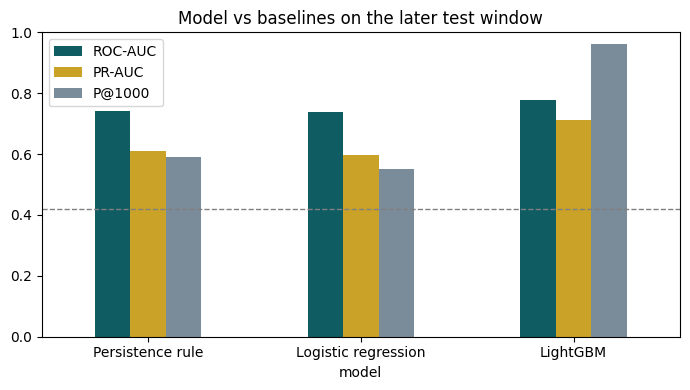

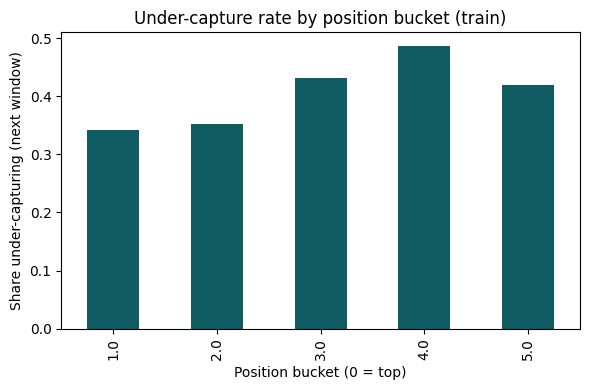

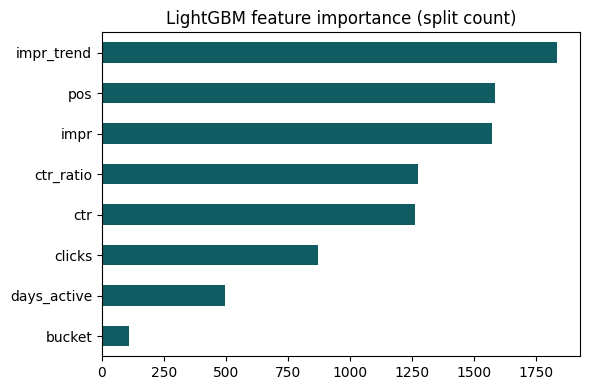

 page_id     pos     impr    ctr  ctr_ratio   risk                                                                      reasons
00af9477  2.3405 352607.0 0.0013     0.2115 0.9891 LOW_CTR_FOR_POSITION, HIGH_VISIBILITY, HIGH_IMPRESSIONS, GROWING_IMPRESSIONS
21e5538d  5.8845 222311.0 0.0002     0.0549 0.9964                  LOW_CTR_FOR_POSITION, HIGH_IMPRESSIONS, GROWING_IMPRESSIONS
9151f434  1.7721 201686.0 0.0002     0.0386 0.9950 LOW_CTR_FOR_POSITION, HIGH_VISIBILITY, HIGH_IMPRESSIONS, GROWING_IMPRESSIONS
fccd9bf7  8.4584 196408.0 0.0002     0.0807 0.9959                  LOW_CTR_FOR_POSITION, HIGH_IMPRESSIONS, GROWING_IMPRESSIONS
b97b9445 10.1719 151231.0 0.0000     0.0030 0.9716                LOW_CTR_FOR_POSITION, HIGH_IMPRESSIONS, DECLINING_IMPRESSIONS
77dc4b9a  4.0995 186811.0 0.0012     0.2380 0.9933                      LOW_CTR_FOR_POSITION, HIGH_VISIBILITY, HIGH_IMPRESSIONS
35120621  7.8643 136324.0 0.0002     0.0689 0.9942                                       LOW_CTR_FOR_POS

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import os, json, hashlib
import matplotlib.pyplot as plt
os.makedirs('docs/figures', exist_ok=True)

# 1) Bootstrap: LightGBM minus persistence ROC-AUC (95% interval)
rng = np.random.default_rng(42)
yv = y_te.values; sg = scores['LightGBM']; sb = scores['Persistence rule']
diffs = []
for _ in range(200):
    i = rng.integers(0, len(yv), len(yv))
    diffs.append(roc_auc_score(yv[i], sg[i]) - roc_auc_score(yv[i], sb[i]))
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f'ROC-AUC gain (LightGBM - persistence): {np.mean(diffs):.4f}  95% interval [{lo:.4f}, {hi:.4f}]')

# 2) Who are the top-1000 pages? (sanity check for P@1000)
test_df = test_df.assign(risk=sg)
top1k = test_df.nlargest(1000, 'risk')
print('top1000 median impressions:', int(top1k.impr.median()), '| all test median:', int(test_df.impr.median()))
print('top1000 position-bucket share:\n', top1k.bucket.value_counts(normalize=True).sort_index().round(3).to_string())

# 3) Figures
m = results.set_index('model')[['ROC-AUC', 'PR-AUC', f'P@{K}']]
ax = m.plot(kind='bar', figsize=(7, 4), color=['#0f5c63', '#c9a227', '#7a8b99'])
ax.axhline(y_te.mean(), color='grey', ls='--', lw=1)
ax.set_ylim(0, 1); ax.set_title('Model vs baselines on the later test window'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig('docs/figures/fig2_model_vs_baseline.png', dpi=160); plt.show()

train_df.groupby('bucket')['label'].mean().plot(kind='bar', figsize=(6, 4), color='#0f5c63')
plt.xlabel('Position bucket (0 = top)'); plt.ylabel('Share under-capturing (next window)')
plt.title('Under-capture rate by position bucket (train)')
plt.tight_layout(); plt.savefig('docs/figures/fig1_undercapture_by_bucket.png', dpi=160); plt.show()

pd.Series(gbm.feature_importances_, index=FEAT_LGB).sort_values().plot(kind='barh', figsize=(6, 4), color='#0f5c63')
plt.title('LightGBM feature importance (split count)')
plt.tight_layout(); plt.savefig('docs/figures/fig3_feature_importance.png', dpi=160); plt.show()

# 4) Reason codes + ranked list (page IDs hashed)
q75 = test_df['impr'].quantile(0.75)
def reasons(r):
    c = []
    if r['ctr_ratio'] < UNDER_RATIO: c.append('LOW_CTR_FOR_POSITION')
    if r['pos'] <= 5: c.append('HIGH_VISIBILITY')
    if r['impr'] >= q75: c.append('HIGH_IMPRESSIONS')
    if r['impr_trend'] < 0.85: c.append('DECLINING_IMPRESSIONS')
    if r['impr_trend'] > 1.2: c.append('GROWING_IMPRESSIONS')
    return ', '.join(c) or 'MODEL_ONLY_SIGNAL'
test_df['reasons'] = test_df.apply(reasons, axis=1)
test_df['opportunity'] = test_df['impr'] * (1 - test_df['ctr_ratio'].clip(0, 1))
test_df['priority'] = test_df['risk'] * test_df['opportunity']
test_df['page_id'] = test_df['page'].astype(str).map(lambda s: hashlib.sha256(s.encode()).hexdigest()[:8])
top = test_df.nlargest(20, 'priority')[['page_id', 'pos', 'impr', 'ctr', 'ctr_ratio', 'risk', 'reasons']].round(4)
top.to_csv('docs/top_recommendations_hashed.csv', index=False)
print(top.head(10).to_string(index=False))
print(test_df['reasons'].str.split(', ').explode().value_counts().to_string())

# 5) Save summary for the paper
summary = {'train_cutoff': str(TRAIN_CUTOFF.date()), 'test_cutoff': str(TEST_CUTOFF.date()),
           'n_train': int(len(train_df)), 'n_test': int(len(test_df)),
           'pos_rate_train': round(float(y_tr.mean()), 4), 'pos_rate_test': round(float(y_te.mean()), 4),
           'test_pages_seen_in_train_pct': 83.1, 'results': results.to_dict(orient='records'),
           'roc_gain_mean': round(float(np.mean(diffs)), 4), 'roc_gain_ci95': [round(float(lo), 4), round(float(hi), 4)]}
json.dump(summary, open('docs/results_summary.json', 'w'), indent=2)

# 6) Download everything
!zip -qr capstone_outputs.zip docs
from google.colab import files
files.download('capstone_outputs.zip')